In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, r2_score, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

# Regression Models
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

df = pd.read_csv("J:\\Machine Learning Projects\\Project-4(ML LPU Proj)\\dstrIPC_2013.csv")
print(df.head())
print(df.info())

         STATE/UT   DISTRICT  YEAR  MURDER  ATTEMPT TO MURDER  \
0  Andhra Pradesh   ADILABAD  2013      96                 72   
1  Andhra Pradesh  ANANTAPUR  2013     156                149   
2  Andhra Pradesh   CHITTOOR  2013      72                 61   
3  Andhra Pradesh   CUDDAPAH  2013      93                107   
4  Andhra Pradesh  CYBERABAD  2013     162                123   

   CULPABLE HOMICIDE NOT AMOUNTING TO MURDER  RAPE  CUSTODIAL RAPE  \
0                                         13    61               0   
1                                          3    28               0   
2                                          2    31               0   
3                                          7    19               0   
4                                         16   138               0   

   OTHER RAPE  KIDNAPPING & ABDUCTION  ...  ARSON  HURT/GREVIOUS HURT  \
0          61                      65  ...     30                2394   
1          28                     110  ...


Missing Values:
STATE/UT                                               0
DISTRICT                                               0
YEAR                                                   0
MURDER                                                 0
ATTEMPT TO MURDER                                      0
CULPABLE HOMICIDE NOT AMOUNTING TO MURDER              0
RAPE                                                   0
CUSTODIAL RAPE                                         0
OTHER RAPE                                             0
KIDNAPPING & ABDUCTION                                 0
KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS            0
KIDNAPPING AND ABDUCTION OF OTHERS                     0
DACOITY                                                0
PREPARATION AND ASSEMBLY FOR DACOITY                   0
ROBBERY                                                0
BURGLARY                                               0
THEFT                                                  0
AUTO THEFT    

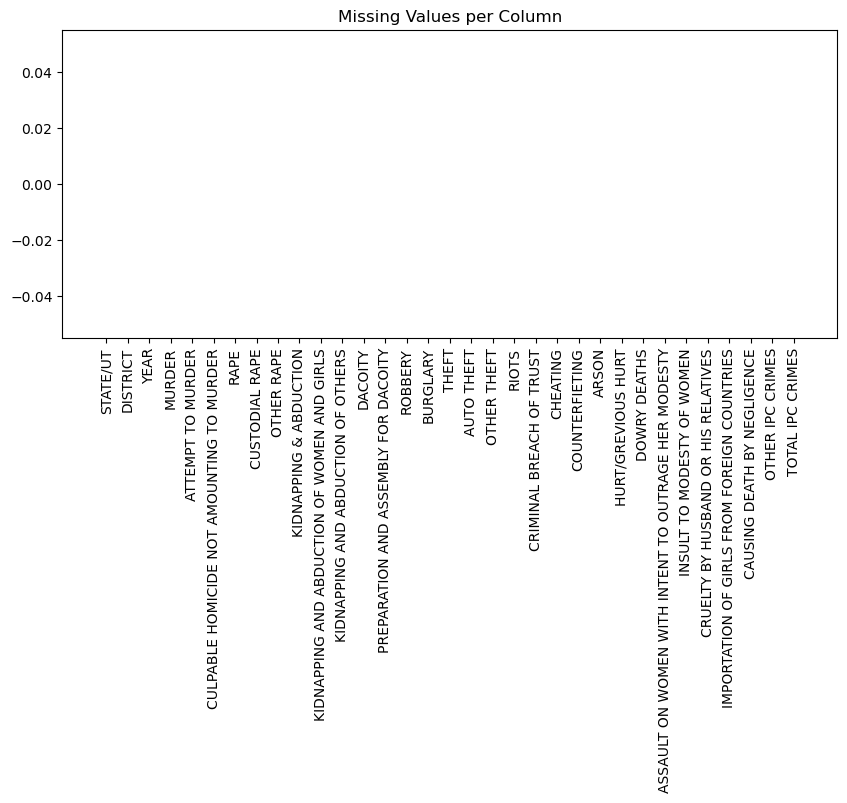

In [4]:
print("\nMissing Values:")
print(df.isnull().sum())

# Visual representation
plt.figure(figsize=(10,4))
plt.bar(df.columns, df.isnull().sum())
plt.xticks(rotation=90)
plt.title("Missing Values per Column")
plt.show()


In [5]:
duplicates = df.duplicated().sum()
print("\nNumber of Duplicate Rows:", duplicates)



Number of Duplicate Rows: 0


C:\Users\adity\AppData\Local\Temp\ipykernel_34704\1437394343.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[col] for col in crime_columns], labels=crime_columns)


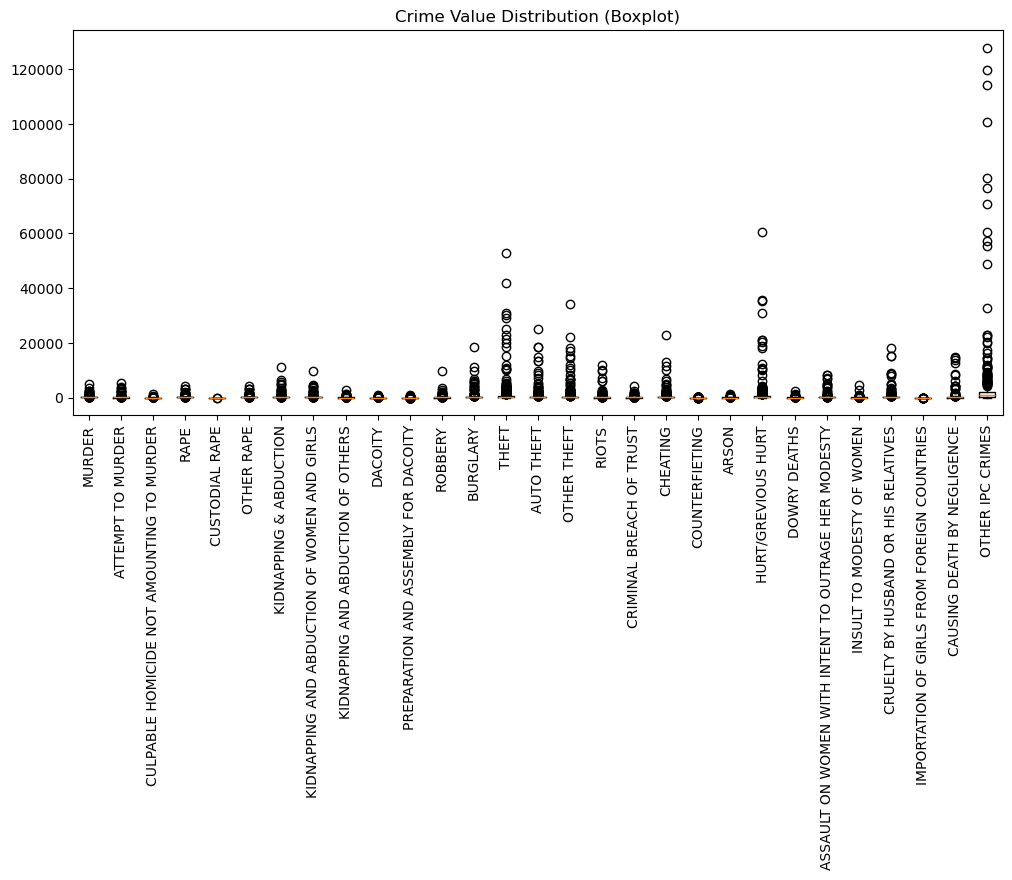

In [6]:
crime_columns = df.columns[3:-1]  # all crime numeric columns

plt.figure(figsize=(12,5))
plt.boxplot([df[col] for col in crime_columns], labels=crime_columns)
plt.xticks(rotation=90)
plt.title("Crime Value Distribution (Boxplot)")
plt.show()


In [7]:
from scipy.stats import zscore

z_scores = np.abs(zscore(df[crime_columns]))
outliers = (z_scores > 3).sum()
print("\nOutliers detected per column:")
print(outliers)



Outliers detected per column:
301


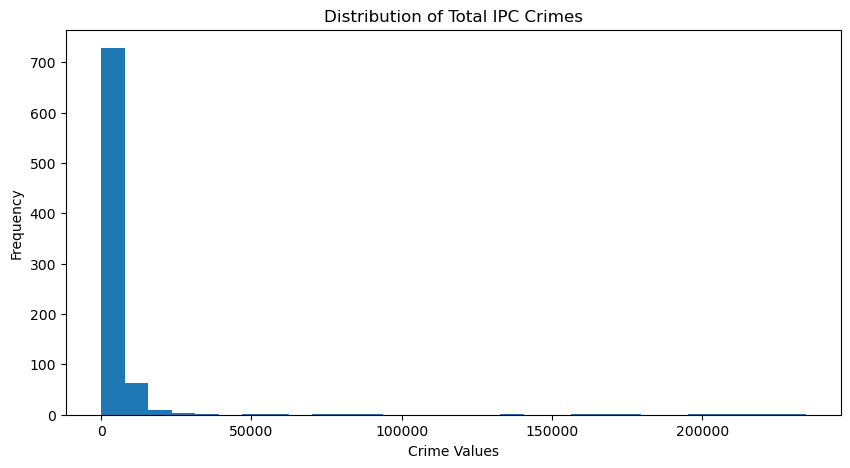

In [8]:
plt.figure(figsize=(10,5))
plt.hist(df['TOTAL IPC CRIMES'], bins=30)
plt.title("Distribution of Total IPC Crimes")
plt.xlabel("Crime Values")
plt.ylabel("Frequency")
plt.show()


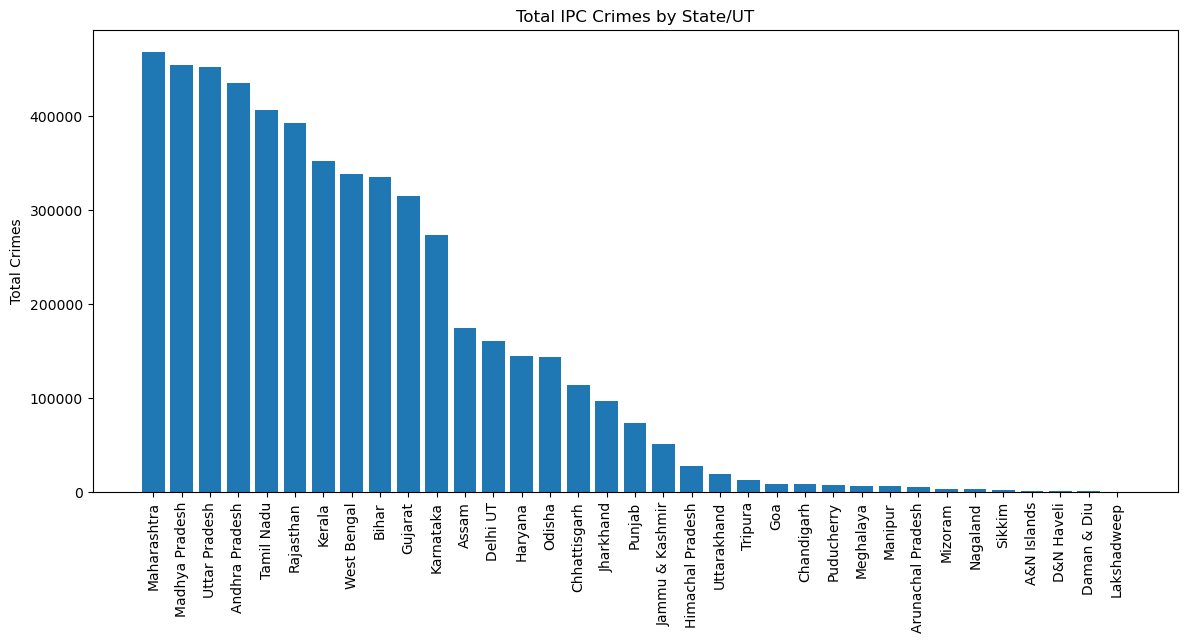

In [9]:
state_crime = df.groupby("STATE/UT")["TOTAL IPC CRIMES"].sum().sort_values(ascending=False)

plt.figure(figsize=(14,6))
plt.bar(state_crime.index, state_crime.values)
plt.xticks(rotation=90)
plt.title("Total IPC Crimes by State/UT")
plt.ylabel("Total Crimes")
plt.show()


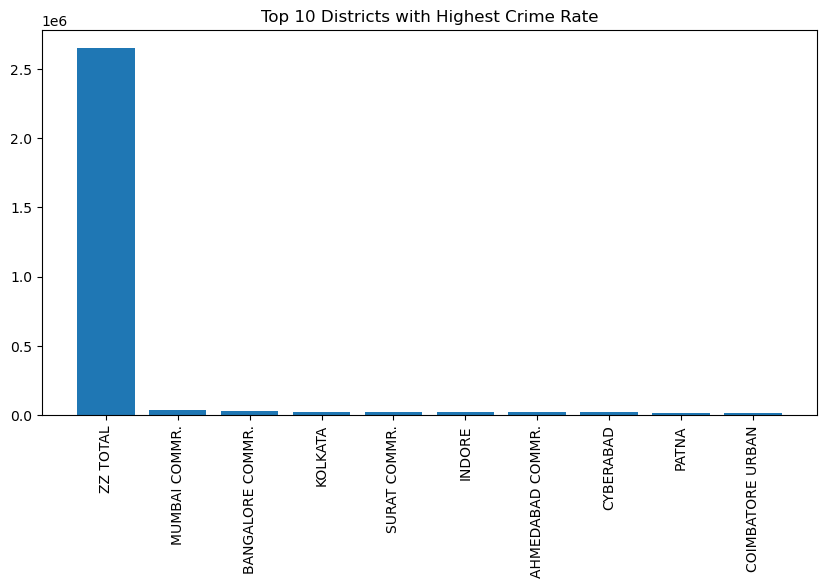

In [10]:
top_districts = df.groupby("DISTRICT")["TOTAL IPC CRIMES"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_districts.index, top_districts.values)
plt.xticks(rotation=90)
plt.title("Top 10 Districts with Highest Crime Rate")
plt.show()


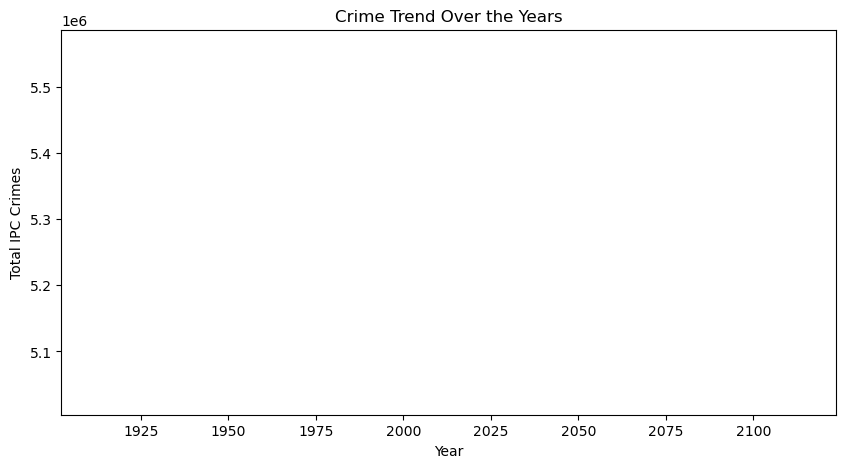

In [11]:
year_trend = df.groupby("YEAR")["TOTAL IPC CRIMES"].sum()

plt.figure(figsize=(10,5))
plt.plot(year_trend.index, year_trend.values)
plt.title("Crime Trend Over the Years")
plt.xlabel("Year")
plt.ylabel("Total IPC Crimes")
plt.show()


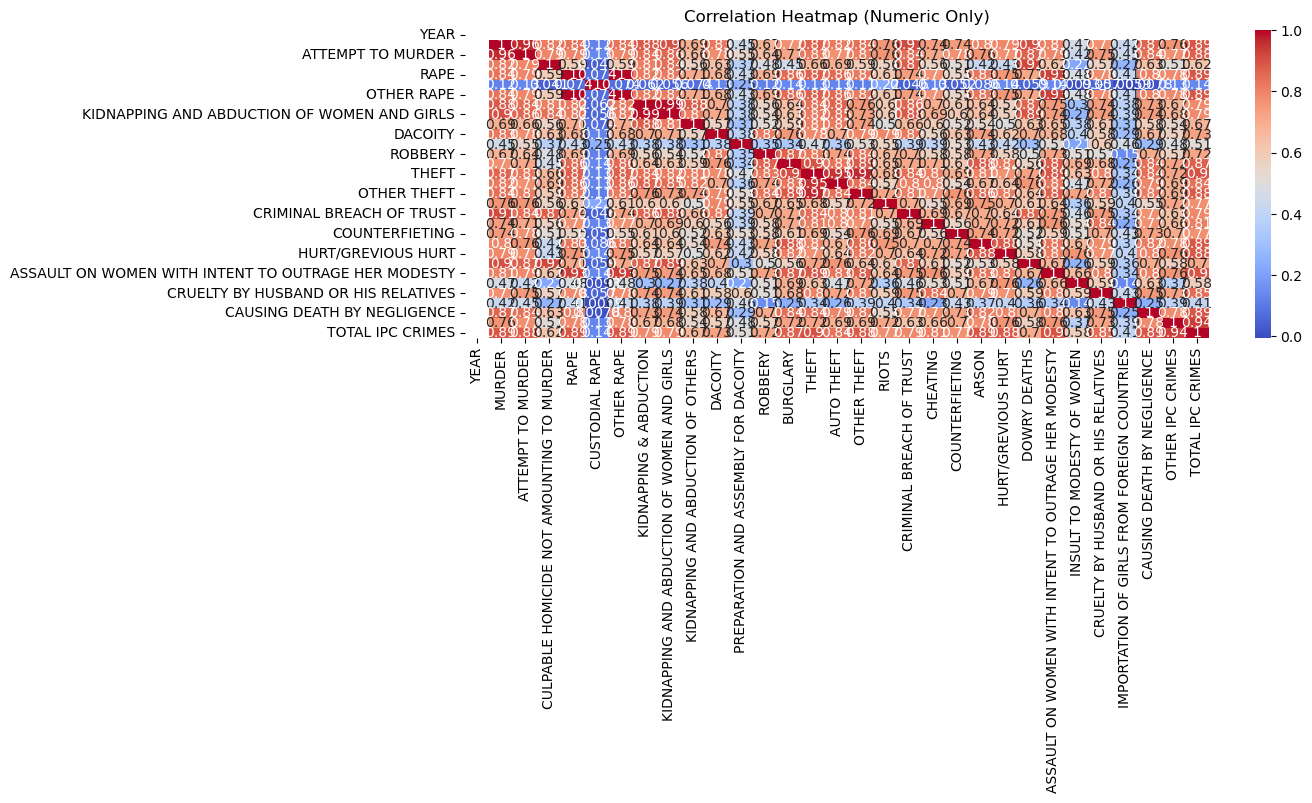

In [12]:
import seaborn as sns

numeric_df = df.select_dtypes(include=['int64', 'float64'])


plt.figure(figsize=(12, 4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Only)")
plt.show()



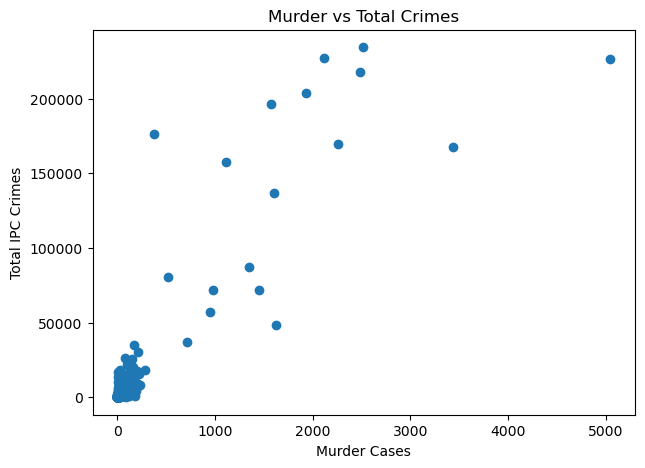

In [13]:
plt.figure(figsize=(7,5))
plt.scatter(df['MURDER'], df['TOTAL IPC CRIMES'])
plt.xlabel("Murder Cases")
plt.ylabel("Total IPC Crimes")
plt.title("Murder vs Total Crimes")
plt.show()


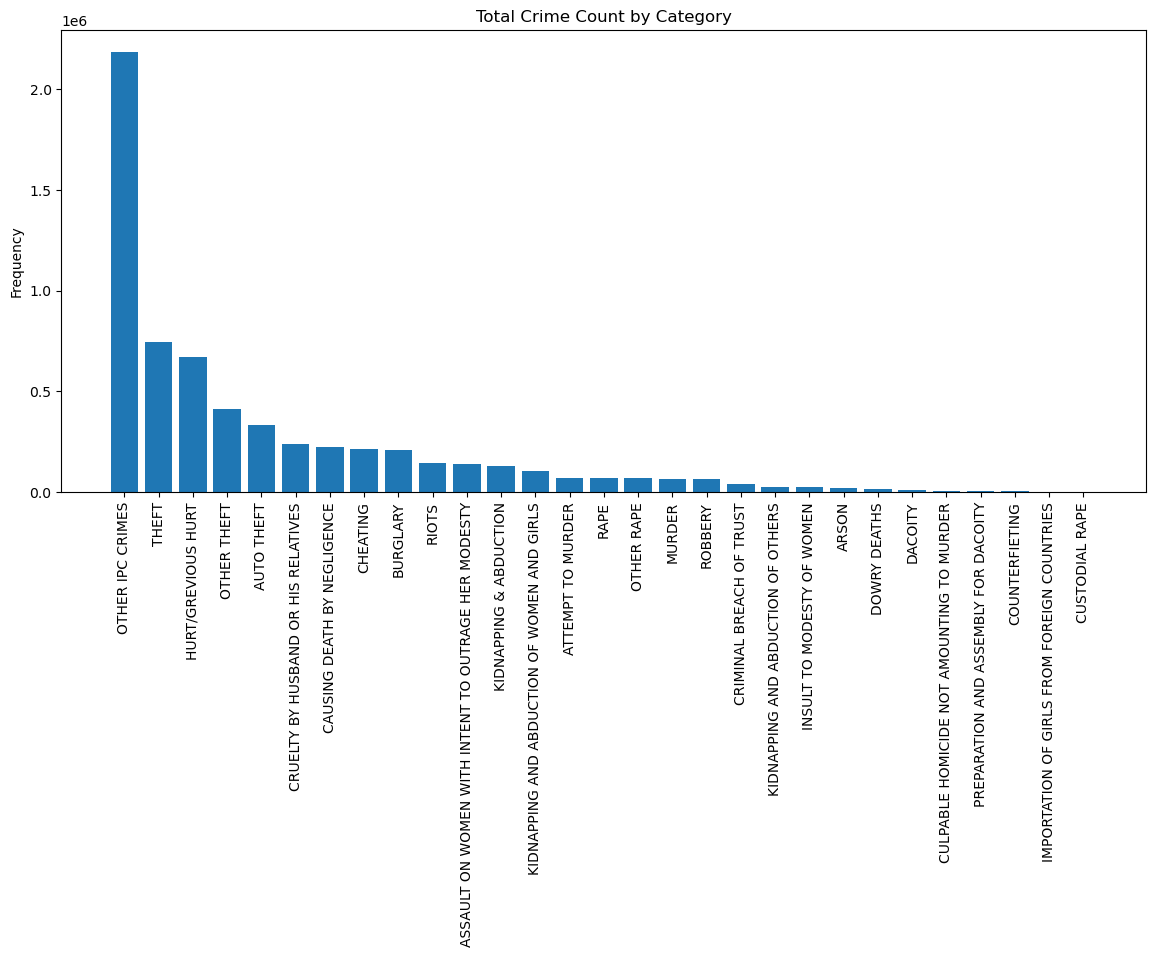

In [14]:
crime_sum = df[crime_columns].sum().sort_values(ascending=False)

plt.figure(figsize=(14,6))
plt.bar(crime_sum.index, crime_sum.values)
plt.xticks(rotation=90)
plt.title("Total Crime Count by Category")
plt.ylabel("Frequency")
plt.show()


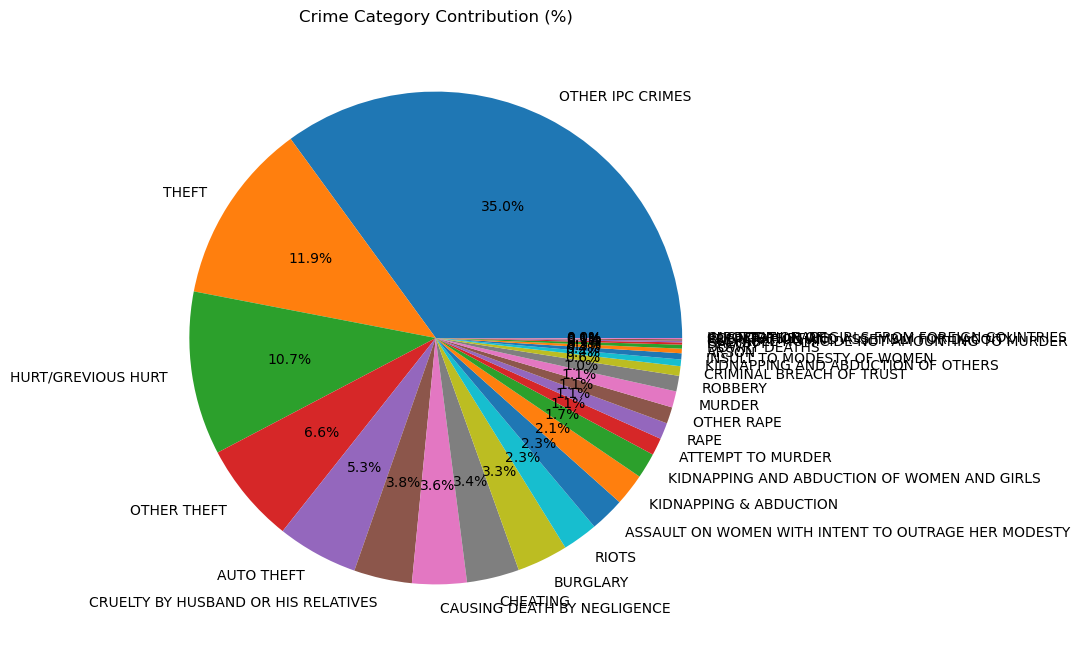

In [15]:
plt.figure(figsize=(8,8))
plt.pie(crime_sum.values, labels=crime_sum.index, autopct="%1.1f%%")
plt.title("Crime Category Contribution (%)")
plt.show()


In [16]:
# FEATURE SELECTION

In [17]:
df = df.copy()

le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col].astype(str))


In [18]:
X = df.drop(columns=['TOTAL IPC CRIMES'])
y = df['TOTAL IPC CRIMES']


In [19]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[numeric_cols])

print("Scaling completed successfully!")


Scaling completed successfully!


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print("X_scaled created successfully!")
print("Train and test split completed.")


X_scaled created successfully!
Train and test split completed.


In [21]:
# SUPERVISED MODELS

In [22]:
# Regression Models
from sklearn.metrics import (
    accuracy_score, r2_score, mean_absolute_error, 
    mean_squared_error, confusion_matrix, classification_report
)
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

print("\n================ REGRESSION MODELS ================")

def eval_regression(model_name, y_test, y_pred):
    print(f"\n----- {model_name} -----")
    print("R2 Score:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
eval_regression("Linear Regression", y_test, lr.predict(X_test))

# 2. Lasso Regression
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
eval_regression("Lasso Regression", y_test, lasso.predict(X_test))

# 3. Ridge Regression
ridge = Ridge(alpha=1)
ridge.fit(X_train, y_train)
eval_regression("Ridge Regression", y_test, ridge.predict(X_test))

# 4. Decision Tree Regressor
dtr = DecisionTreeRegressor()
dtr.fit(X_train, y_train)
eval_regression("Decision Tree Regression", y_test, dtr.predict(X_test))

# 5. Random Forest Regressor
rfr = RandomForestRegressor(n_estimators=20)
rfr.fit(X_train, y_train)
eval_regression("Random Forest Regression", y_test, rfr.predict(X_test))



# =====================================================
#                CLASSIFICATION MODELS


print("\n================ CLASSIFICATION MODELS ================")

def eval_classification(model_name, y_test, y_pred):
    print(f"\n----- {model_name} -----")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 6. Logistic Regression
logr = LogisticRegression(max_iter=10)
logr.fit(X_train, y_train)
eval_classification("Logistic Regression", y_test, logr.predict(X_test))

# 7. Decision Tree Classifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
eval_classification("Decision Tree Classifier", y_test, dtc.predict(X_test))

# 8. Random Forest Classifier
rfc = RandomForestClassifier(n_estimators=10)
rfc.fit(X_train, y_train)
eval_classification("Random Forest Classifier", y_test, rfc.predict(X_test))

# 9. KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
eval_classification("KNN Classifier", y_test, knn.predict(X_test))

# 10. SVM Classifier
svm = SVC()
svm.fit(X_train, y_train)
eval_classification("SVM Classifier", y_test, svm.predict(X_test))


================ REGRESSION MODELS ================

----- Linear Regression -----
R2 Score: 1.0
MAE: 5.674695730152907e-12
MSE: 1.642968692124075e-22
RMSE: 1.2817834029679411e-11

----- Lasso Regression -----
R2 Score: 0.9999968943281661
MAE: 19.67577488101045
MSE: 2516.4161405466516
RMSE: 50.16389279697751

----- Ridge Regression -----
R2 Score: 0.9999707649385047
MAE: 48.3895484103391
MSE: 23688.137237382885
RMSE: 153.90950989910561

----- Decision Tree Regression -----
R2 Score: 0.9813883370871597
MAE: 1253.4848484848485
MSE: 15080372.76969697
RMSE: 3883.3455640332822

----- Random Forest Regression -----
R2 Score: 0.9689052530814641
MAE: 1185.4284848484851
MSE: 25194974.619242433
RMSE: 5019.459594343044

================ CLASSIFICATION MODELS ================

----- Logistic Regression -----
Accuracy: 0.0

Confusion Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Classification Report:
             

c:\Users\adity\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1201: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\adity\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and 


----- Decision Tree Classifier -----
Accuracy: 0.0

Confusion Matrix:
 [[0 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Classification Report:
               precision    recall  f1-score   support

          20       0.00      0.00      0.00       0.0
          24       0.00      0.00      0.00       1.0
          35       0.00      0.00      0.00       0.0
          40       0.00      0.00      0.00       2.0
          41       0.00      0.00      0.00       0.0
          47       0.00      0.00      0.00       1.0
          50       0.00      0.00      0.00       1.0
          53       0.00      0.00      0.00       0.0
          56       0.00      0.00      0.00       0.0
          84       0.00      0.00      0.00       1.0
          88       0.00      0.00      0.00       1.0
         105       0.00      0.00      0.00       1.0
         119       0.00      0.00      0.00       0.0
         128       0.00   

c:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adity\anaconda3\Lib\site-pa


----- Random Forest Classifier -----
Accuracy: 0.0

Confusion Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Classification Report:
               precision    recall  f1-score   support

          12       0.00      0.00      0.00       0.0
          14       0.00      0.00      0.00       0.0
          20       0.00      0.00      0.00       0.0
          24       0.00      0.00      0.00       1.0
          28       0.00      0.00      0.00       0.0
          40       0.00      0.00      0.00       2.0
          47       0.00      0.00      0.00       1.0
          50       0.00      0.00      0.00       1.0
          78       0.00      0.00      0.00       0.0
          82       0.00      0.00      0.00       0.0
          84       0.00      0.00      0.00       1.0
          85       0.00      0.00      0.00       0.0
          87       0.00      0.00      0.00       0.0
          88       0.00   

c:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adity\anaconda3\Lib\site-pa


----- SVM Classifier -----
Accuracy: 0.0

Confusion Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [2 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Classification Report:
               precision    recall  f1-score   support

          15       0.00      0.00      0.00       0.0
          24       0.00      0.00      0.00       1.0
          40       0.00      0.00      0.00       2.0
          47       0.00      0.00      0.00       1.0
          50       0.00      0.00      0.00       1.0
          84       0.00      0.00      0.00       1.0
          88       0.00      0.00      0.00       1.0
         105       0.00      0.00      0.00       1.0
         128       0.00      0.00      0.00       1.0
         155       0.00      0.00      0.00       1.0
         164       0.00      0.00      0.00       1.0
         173       0.00      0.00      0.00       1.0
         189       0.00      0.00      0.00       0.0
         248       0.00      0.00   

c:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\adity\anaconda3\Lib\site-pa

In [24]:
import joblib

# Save trained crime model
joblib.dump(model, "crime_model.joblib")

# Save scaler
joblib.dump(scaler, "crime_scaler.joblib")

# Save feature column names
joblib.dump(X.columns.tolist(), "crime_columns.joblib")

print("Model, scaler, and columns saved successfully!")


NameError: name 'model' is not defined